In [1]:
import os
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


In [2]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

data_path = PROJECT_ROOT / "data" / "raw" / "dataset"
image_paths = []
labels = []
categories = []

for category_dir in sorted(data_path.iterdir()):
    if not category_dir.is_dir():
        continue

    for file_path in sorted(category_dir.iterdir()):
        if file_path.suffix.lower() not in {".png", ".jpg", ".jpeg"}:
            continue

        image_paths.append(str(file_path))
        labels.append(file_path.stem)
        categories.append(category_dir.name)

print("Total images:", len(image_paths))
print("Categories:", len(set(categories)))


Total images: 3482
Categories: 10


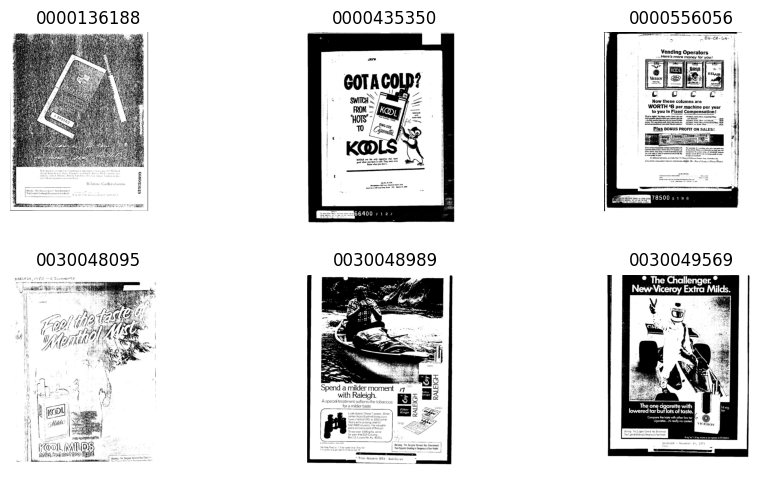

In [3]:
plt.figure(figsize=(10, 5))
sample_count = min(6, len(image_paths))

for i in range(sample_count):
    img = cv2.imread(image_paths[i])
    if img is None:
        raise ValueError(f"Failed to load image: {image_paths[i]}")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(labels[i][:20])
    plt.axis("off")

plt.tight_layout()
plt.show()


Since this dataset lacks structured ground truth, I plan to:
- use provided Renaissance PDFs with transcription
- or manually annotate a subset

## Problem Understanding

Historical document OCR presents unique challenges:
- Degraded text quality
- Non-standard fonts and spelling
- Noise and artifacts

To address this, I propose a CNN-RNN-CTC pipeline:
1. CNN extracts visual features
2. Sequence modeling via BiLSTM
3. CTC loss for alignment-free training
4. Beam search decoding
5. LLM-based correction for improved transcription

This hybrid approach combines deep learning with language modeling.

In [4]:
def preprocess(img_path, target_size=(128, 32), crop_top_ratio=0.3):
    img_path = Path(img_path)
    if not img_path.exists():
        raise ValueError(f"Path does not exist: {img_path}")

    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Failed to load image: {img_path}")

    h, _ = img.shape
    crop_end = max(1, int(h * crop_top_ratio))
    img = img[:crop_end, :]
    img = cv2.resize(img, target_size)
    img = img.astype(np.float32) / 255.0

    return img


In [5]:
print("Sample path:", image_paths[0])
print("Exists:", os.path.exists(image_paths[0]))

img_test = cv2.imread(image_paths[0])
print("Loaded:", img_test is not None)

Sample path: D:\Gsoc\historical-document-ocr\data\raw\dataset\ADVE\0000136188.jpg
Exists: True
Loaded: True


In [6]:
img = preprocess(image_paths[0])

print("Shape:", img.shape)
print("Min pixel:", img.min())
print("Max pixel:", img.max())

Shape: (32, 128)
Min pixel: 0.0
Max pixel: 1.0


In [7]:
lengths = [len(l) for l in labels]

print("Max length:", max(lengths))
print("Min length:", min(lengths))
print("Avg length:", sum(lengths)/len(lengths))

Max length: 23
Min length: 6
Avg length: 12.330557151062608


In [8]:
print(len(image_paths))
print(len(labels))


3482
3482


In [9]:
filtered = [
    (img_path, lbl)
    for img_path, lbl in zip(image_paths, labels)
    if len(lbl) <= 20
]

image_paths, labels = map(list, zip(*filtered))

print("After filtering:", len(image_paths))


After filtering: 3319


In [10]:
# build character set
blank_token = "<BLANK>"
chars = sorted(set("".join(labels)))

if blank_token in chars:
    raise ValueError(f"Blank token {blank_token!r} already exists in labels")

chars.append(blank_token)

char2idx = {c: i for i, c in enumerate(chars)}
idx2char = {i: c for c, i in char2idx.items()}
blank_idx = char2idx[blank_token]

print("Vocab size:", len(chars))
print("Blank index:", blank_idx)


Vocab size: 45
Blank index: 44


In [11]:
import sys

src_path = PROJECT_ROOT / "src"
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from data.dataset import OCRDataset

In [12]:
dataset = OCRDataset(image_paths, labels, char2idx)


In [13]:
import torch
from torch.utils.data import DataLoader

def collate_fn(batch):
    batch_images, batch_labels = zip(*batch)

    batch_images = torch.stack(batch_images)

    label_lengths = torch.tensor([len(label) for label in batch_labels])
    batch_labels = torch.cat(batch_labels)

    return batch_images, batch_labels, label_lengths

In [14]:
loader = DataLoader(dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)

In [15]:
for batch in loader:
    batch_images, batch_labels, lengths = batch

    print("Images shape:", batch_images.shape)   # (B, 1, 32, 128)
    print("Labels shape:", batch_labels.shape)
    print("Lengths:", lengths)

    break

Images shape: torch.Size([8, 1, 32, 128])
Labels shape: torch.Size([86])
Lengths: tensor([ 8, 15,  8, 11,  8, 13, 13, 10])


In [16]:
print(os.path.exists(image_paths[0]))


True


In [17]:
from models.crnn import CRNN


In [18]:
num_classes = len(chars)

model = CRNN(num_classes)

In [19]:
for batch in loader:
    batch_images, batch_labels, batch_label_lengths = batch

    outputs = model(batch_images)

    print("Input shape:", batch_images.shape)
    print("Output shape:", outputs.shape)

    break

Input shape: torch.Size([8, 1, 32, 128])
Output shape: torch.Size([8, 32, 45])


In [20]:
import torch.nn as nn

ctc_loss = nn.CTCLoss(blank=blank_idx, zero_infinity=True)

In [21]:
outputs = model(batch_images)   # (B, T, C)

outputs = outputs.permute(1, 0, 2)  # (T, B, C)

log_probs = outputs.log_softmax(2)

In [22]:
input_lengths = torch.full(
    size=(batch_images.size(0),),
    fill_value=outputs.size(0),  # T
    dtype=torch.long
)

In [23]:
loss = ctc_loss(
    log_probs,
    batch_labels,
    input_lengths,
    batch_label_lengths
)

print("CTC loss:", loss.item())

CTC loss: 8.716209411621094


In [24]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [26]:
epochs = 3

for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    for batch_images, batch_labels, batch_label_lengths in loader:
        optimizer.zero_grad()

        outputs = model(batch_images)  # (B, T, C)
        log_probs = outputs.permute(1, 0, 2).log_softmax(2)  # (T, B, C)

        input_lengths = torch.full(
            size=(batch_images.size(0),),
            fill_value=log_probs.size(0),
            dtype=torch.long
        )

        loss = ctc_loss(
            log_probs,
            batch_labels,
            input_lengths,
            batch_label_lengths
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    print(f"Epoch {epoch + 1}, Avg loss: {avg_loss:.4f}")


Epoch 1, Avg loss: 2.5411
Epoch 2, Avg loss: 2.5267
Epoch 3, Avg loss: 2.5196


In [27]:
def greedy_decode(output, idx2char):
    """
    output: (T, C)
    """
    pred = output.argmax(dim=1)  # best char at each timestep

    decoded = []
    prev = -1

    for p in pred:
        p = p.item()

        # remove duplicates + blank
        if p != prev and idx2char[p] != "_":
            decoded.append(idx2char[p])

        prev = p

    return "".join(decoded)

In [28]:
model.eval()

for batch in loader:
    images, labels, lengths = batch

    outputs = model(images)  # (B, T, C)

    break

In [29]:
sample_output = outputs[0]   # (T, C)

pred_text = greedy_decode(sample_output, idx2char)

print("Predicted:", pred_text)

Predicted: 20<BLANK>


In [30]:
for i in range(5):
    pred = greedy_decode(outputs[i], idx2char)
    print(f"Sample {i}: {pred}")

Sample 0: 20<BLANK>
Sample 1: 20<BLANK>
Sample 2: 20<BLANK>
Sample 3: 20<BLANK>
Sample 4: 20<BLANK>
